In [1]:
import os
os.environ['NUMEXPR_MAX_THREADS'] = '35'
from functionsgpu_fast import *

import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import pickle
from plotting_beta import *
torch.set_default_device('cuda:1')
device = torch.device('cuda:1')

import warnings
warnings.filterwarnings("ignore")

kin_marker_list = [
    "LFHD",
    "RFHD",
    "LBHD",
    "RBHD",
    "C7",
    "T10",
    "CLAV",
    "STRN",
    "LSHO",
    "LELB",
    "LWRA",
    "LWRB",
    "LFIN",
    "RSHO",
    "RELB",
    "RWRA",
    "RWRB",
    "RFIN",
    "LASI",
    "RASI",
    "LTHI",
    "LKNE",
    "LTIB",
    "LANK",
    "LHEE",
    "LTOE",
    "RTHI",
    "RKNE",
    "RTIB",
    "RANK",
    "RHEE",
    "RTOE",
]

def landmark_2Darray_to_dict(landmark_array, marker_list):
    num_time_points = landmark_array.shape[0]
    num_markers = len(marker_list)
    marker_dict = {}

    for i, marker in enumerate(marker_list):
        start_idx = i * 3
        end_idx = start_idx + 3
        coords = landmark_array[:, start_idx:end_idx]  # shape (337, 3)

        # Add confidence column (set to 1.0)
        confidence = np.ones((num_time_points, 1))
        coords_with_conf = np.hstack((coords, confidence))  # shape (337, 4)

        marker_dict[marker] = coords_with_conf

    return marker_dict

tslen = 200

## Loading Data

In [2]:
data_folder = "/mnt/sdb/arafat/stroke_riemann/csv_r"
files = [file for file in os.listdir(data_folder)]
files = sorted(files, key=lambda x: int(x.split('_')[0][2:]))

all_data = {}

for f in files:
    file_path = os.path.join(data_folder, f)
    g = pd.read_csv(file_path)
    
    gait_cycles = g.iloc[:,:-1].values
    n_rows = gait_cycles.shape[0]
    # Reshape: (n_rows, 96) -> (n_rows, 32, 3) -> transpose to (32, 3, n_rows)
    result = gait_cycles.reshape(n_rows, 32, 3).transpose(1, 2, 0)
    pid = f.split('_')[0][2:]
    all_data[pid] = result

keys = list(all_data.keys())
data_stroke = {k: all_data[k] for k in keys[:44]}
data_healthy = {k: all_data[k] for k in keys[44:]}
len(data_stroke.keys()), len(data_healthy.keys())

(44, 111)

## Unprocessed Data Saving

In [ ]:
# from scipy.interpolate import interp1d

# def resample_kinematic(data, gamma_t):
#     pids = data.keys()
#     betas_resampled = []

#     for i, pid in enumerate(pids):
#         beta = data[pid]
#         t = np.linspace(0, 1, beta.shape[2])

#         interp_func = interp1d(t, beta, kind='linear', axis=2, fill_value='extrapolate')
#         beta_resampled = interp_func(gamma_t)  # shape (32, 3, n_rows)
#         betas_resampled.append(beta_resampled)

#     return betas_resampled

# gamma_t = np.linspace(0, 1, tslen)
# stroke_resampled = resample_kinematic(data_stroke, gamma_t)
# healthy_resampled = resample_kinematic(data_healthy, gamma_t)

# betas_raw = stroke_resampled + healthy_resampled
# print(betas_raw[0].shape)
# betas_raw = np.array(betas_raw)
# print(betas_raw.shape)

# with open('unaligned_betas.pkl', 'wb') as f:
#     pickle.dump(betas_raw, f)

In [6]:
# with open("data_stroke.pkl", "wb") as f:
#     pickle.dump(data_stroke, f, protocol=pickle.HIGHEST_PROTOCOL)

## Resampling and Getting into Kendall Shape Space

In [5]:
gamma_t = np.linspace(0, 1, tslen)
betas_resampled_stroke = process_kinematic(data_stroke, gamma_t)
betas_resampled_healthy = process_kinematic(data_healthy, gamma_t)

print(len(betas_resampled_stroke), len(betas_resampled_healthy))

44 111


In [8]:
betas_all = betas_resampled_stroke + betas_resampled_healthy
betas_all_arr = np.array(betas_all)
print(betas_all_arr.shape)

# with open('kendall_no_rot_align.pkl', 'wb') as f:
#     pickle.dump(betas_all_arr, f)

(155, 32, 3, 200)


In [ ]:
# %matplotlib qt5
# beta = betas_all[12]
# beta = beta.transpose(2, 0, 1).reshape(tslen, 96)
# beta = landmark_2Darray_to_dict(beta, kin_marker_list)
# a = plotting_beta_landmark(beta)

## Euclidean Mean

In [ ]:
# betas_euclidean_mean = np.mean(betas_raw, axis=0)
# print(betas_euclidean_mean.shape)

# with open('euclidean_mean.pkl', 'wb') as f:
#     pickle.dump(betas_euclidean_mean, f)

In [ ]:
# kendall_euclidean_mean = np.mean(betas_all_arr, axis=0)
# print(kendall_euclidean_mean.shape)

# with open('kendall_euclidean_mean.pkl', 'wb') as f:
#     pickle.dump(kendall_euclidean_mean, f)

In [ ]:
# %matplotlib qt5
# betas_euclidean_mean = betas_euclidean_mean.transpose(2, 0, 1).reshape(tslen, 96)
# betas_euclidean_mean = betas_euclidean_mean/1000
# betas_euclidean_mean = landmark_2Darray_to_dict(betas_euclidean_mean, kin_marker_list)
# p_euclidean = plotting_beta_landmark(betas_euclidean_mean, zoom=1.2)

## Getting frechet mean

  0%|          | 0/5 [00:00<?, ?it/s]

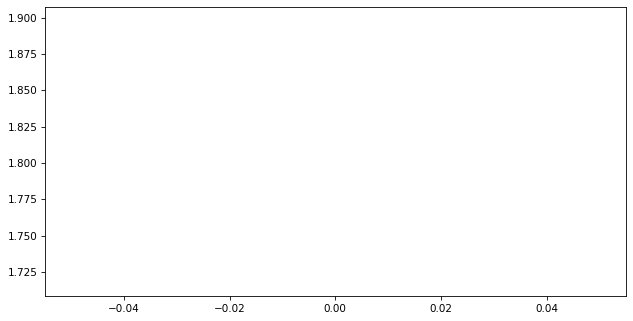

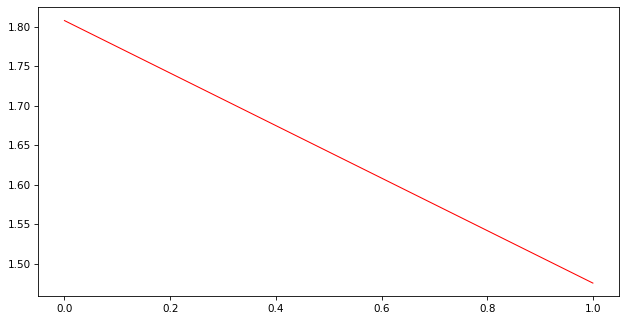

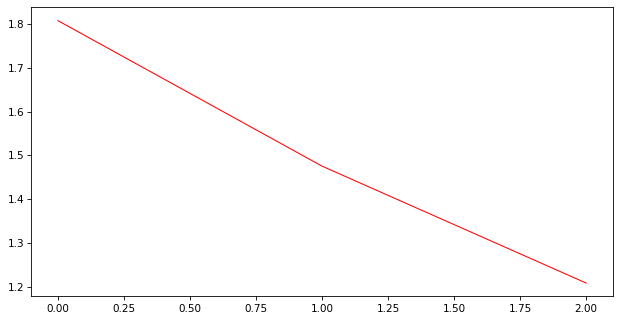

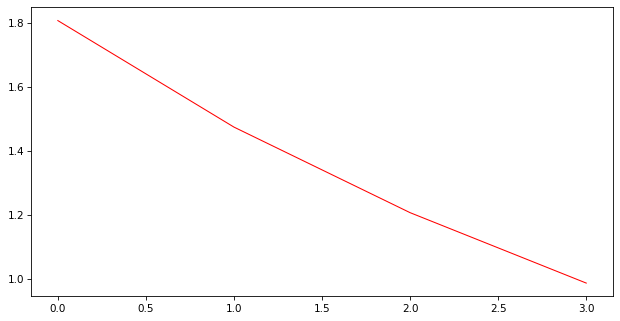

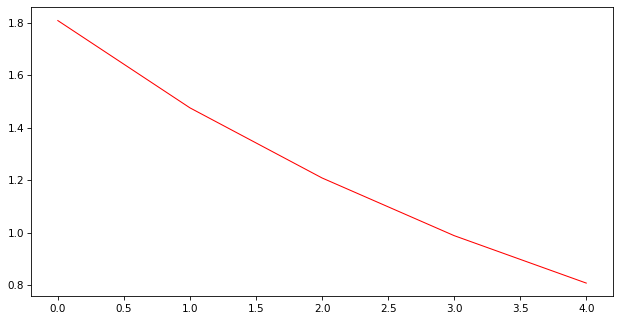

In [10]:
%matplotlib inline
mu_init = betas_resampled_healthy[np.random.choice(range(len(betas_resampled_healthy)))]
mu_all, betas_aligned_all, gammas_all, tangent_vec_all, history_all = frechet(betas_all, gamma_t, mu_init, iterations=5)

## Plotting trajectories of a single landmark

In [ ]:
# def plot_traj(betas_resampled, betas_aligned, gamma_t, gammas, mu):

#     fig, axs = plt.subplots(1, 3, figsize=(3*10, 6))
    
#     N = len(betas_resampled)
    
#     for n in range(N):
    
#       axs[0].plot(gamma_t, betas_resampled[n][0,0,:])
#       axs[1].plot(gamma_t, betas_aligned[n][0,0,:])
#       axs[2].plot(gamma_t, gammas[n])

#     axs[1].plot(gamma_t, mu[0,0,:], color='black',linewidth=4)

#     # axs[0].set_ylim(-0.1, 0.1)
#     # axs[1].set_ylim(-0.1, 0.01)
    
#     plt.tight_layout()

## Saving and loading

In [ ]:
# import pickle
# import time
# import random

# def saving(betas_aligned, mu, gammas, tangent_vecs, filename, tslen):
    
#     with open('{}/betas_aligned{}.pkl'.format(filename, tslen), 'wb') as f:
#         pickle.dump(betas_aligned, f)
#     with open('{}/mu{}.pkl'.format(filename, tslen), 'wb') as f:
#         pickle.dump(mu, f)
#     with open('{}/gammas{}.pkl'.format(filename, tslen), 'wb') as f:
#         pickle.dump(gammas, f)
#     with open('{}/tangent_vecs{}.pkl'.format(filename, tslen), 'wb') as f:
#         pickle.dump(tangent_vecs, f)


In [ ]:
# saving(betas_aligned_all, mu_all, gammas_all, tangent_vec_all, 'aligned_data',tslen)

In [ ]:
# #loading
# def loading(filename, tslen):
#     with open('{}/betas_aligned{}.pkl'.format(filename, tslen), 'rb') as f:
#         betas_aligned = pickle.load(f)
#     with open('{}/mu{}.pkl'.format(filename, tslen), 'rb') as f:
#         mu = pickle.load(f)
#     with open('{}/tangent_vecs{}.pkl'.format(filename, tslen), 'rb') as f:
#         tangent_vec_all = pickle.load(f)
#     with open('{}/gammas{}.pkl'.format(filename, tslen), 'rb') as f:
#         gammas_all = pickle.load(f)
#     return betas_aligned, mu, tangent_vec_all, gammas_all

In [ ]:
# betas_aligned_all, mu_all, tangent_vec_all, gammas_all = loading('aligned_data',tslen)
# len(betas_aligned_all)

In [ ]:
# %matplotlib inline
# plot_traj(betas_raw, betas_aligned_all, gamma_t, gammas_all, mu_all)

In [ ]:
# %matplotlib qt5
# colors = [(1, 0, 0)]*len(betas_resampled_stroke) + [(0, 0.5, 1)]*len(betas_resampled_healthy)
# p = plotting_betas_landmark(betas_aligned_all, colors)

In [ ]:
# fps = 10
    
# # Define the writer with the correct framerate
# writervideo = matplotlib.animation.FFMpegWriter(fps=fps)
# p.to_video("pics_videos/registation_aligned_all.mp4", fps=fps)

In [ ]:
# def save_skeleton(p, filename):
#     fps = 10
    
#     # Define the writer with the correct framerate
#     writervideo = matplotlib.animation.FFMpegWriter(fps=fps)
    
#     # Save the animation with the correct writer
#     p.to_video(filename, fps=fps)

In [ ]:
# %matplotlib qt5
# mu = mu_all.transpose(2, 0, 1).reshape(tslen, 96)
# mu = landmark_2Darray_to_dict(mu, kin_marker_list)
# p_mu_all = plotting_beta_landmark(mu)

In [ ]:
# %matplotlib inline
# for beta, f in zip(betas_aligned_all, files):
#     beta_array = beta.transpose(2, 0, 1).reshape(tslen, 96)
#     ld = landmark_2Darray_to_dict(beta_array, kin_marker_list)
    
#     plt.figure()
#     plt.title(f)
#     plt.plot(ld['RHEE'][:,2], label='Right Heel') # 2 for z-axis
#     plt.plot(ld['LHEE'][:,2], label='Left Heel')
#     plt.legend()
#     plt.show()

In [ ]:
# from scipy.interpolate import interp1d

# data_folder = "/mnt/sdb/arafat/stroke_riemann/csv_r"
# dest_folder = "/mnt/sdb/arafat/stroke_riemann/aligned_csv"
# files = [file for file in os.listdir(data_folder)]
# files = sorted(files, key=lambda x: int(x.split('_')[0][2:]))

# i = 0

# for f in files:
#     file_path = os.path.join(data_folder, f)
#     g = pd.read_csv(file_path)
#     gait_df = g.iloc[:,:-1]
#     n_rows = gait_df.values.shape[0]

#     new_gamma_t = np.linspace(0, 1, n_rows)
#     beta = betas_aligned_all[i]  # shape (32, 3, 200)
#     t_old = np.linspace(0, 1, beta.shape[2])
#     interp_func = interp1d(t_old, beta, kind='linear', axis=2, fill_value='extrapolate')
#     resampled_beta = interp_func(new_gamma_t)  # shape (32, 3, n_rows)
#     resampled_beta = pd.DataFrame(resampled_beta.transpose(2, 0, 1).reshape(resampled_beta.shape[2], 96), columns=gait_df.columns)
#     resampled_beta['Gait'] = g['Gait']
#     resampled_beta.to_csv(os.path.join(dest_folder, f), index=False)

#     i += 1
    

In [ ]:
# from scipy.interpolate import interp1d

# data_folder = "/mnt/sdb/arafat/stroke_riemann/csv_r"
# dest_folder = "/mnt/sdb/arafat/stroke_riemann/tangent_vecs"
# files = [file for file in os.listdir(data_folder)]
# files = sorted(files, key=lambda x: int(x.split('_')[0][2:]))

# i = 0

# for f in files:
#     file_path = os.path.join(data_folder, f)
#     g = pd.read_csv(file_path)
#     gait_df = g.iloc[:,:-1]
#     n_rows = gait_df.values.shape[0]

#     new_gamma_t = np.linspace(0, 1, n_rows)
#     tangent_vec = tangent_vec_all[:,:,:,i]  # shape (32, 3, 200)
#     t_old = np.linspace(0, 1, tangent_vec.shape[2])

#     interp_func = interp1d(t_old, tangent_vec, kind='linear', axis=2, fill_value='extrapolate')
#     resampled_tangent_vec = interp_func(new_gamma_t)  # shape (32, 3, n_rows)
#     # resampled_tangent_vec = tangent_vec
    
#     resampled_tangent_vec = pd.DataFrame(resampled_tangent_vec.transpose(2, 0, 1).reshape(resampled_tangent_vec.shape[2], 96), columns=gait_df.columns)
    
#     window_size = 100
#     num_rows = len(resampled_tangent_vec)

#     gait_id = 1
#     for start in range(0, num_rows, window_size):
#         end = min(start + window_size, num_rows)
#         resampled_tangent_vec.loc[start:end - 1, 'Gait'] = gait_id
#         gait_id += 1

#     resampled_tangent_vec.to_csv(os.path.join(dest_folder, f), index=False)

#     i += 1

In [ ]:
# from plot_frames import *

# output_image_foldername = 'pics_videos/kendall_mean'
# input_video_filename = 'pics_videos/kendall_mean.mp4'

# plot_frames(input_video_filename, output_image_foldername)

In [ ]:
# save_skeleton(p_mu_all, "pics_videos/kendall_mean.mp4")